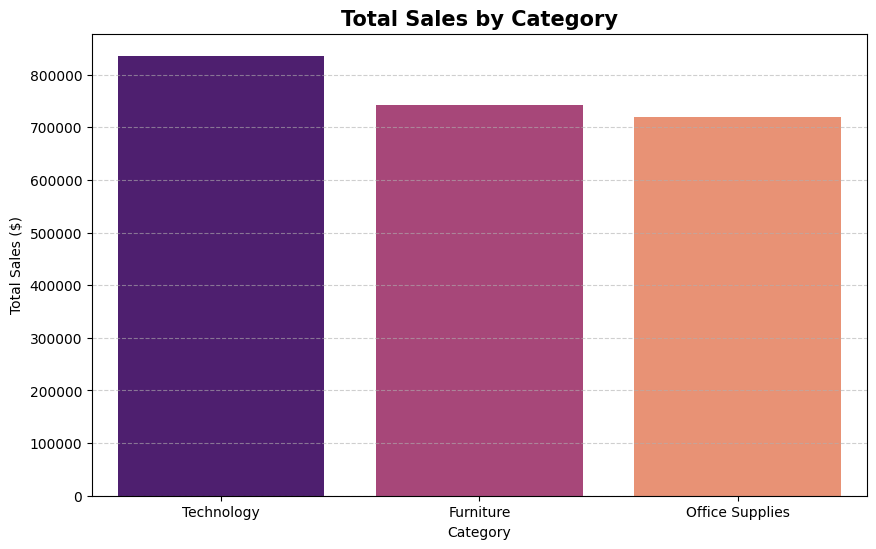

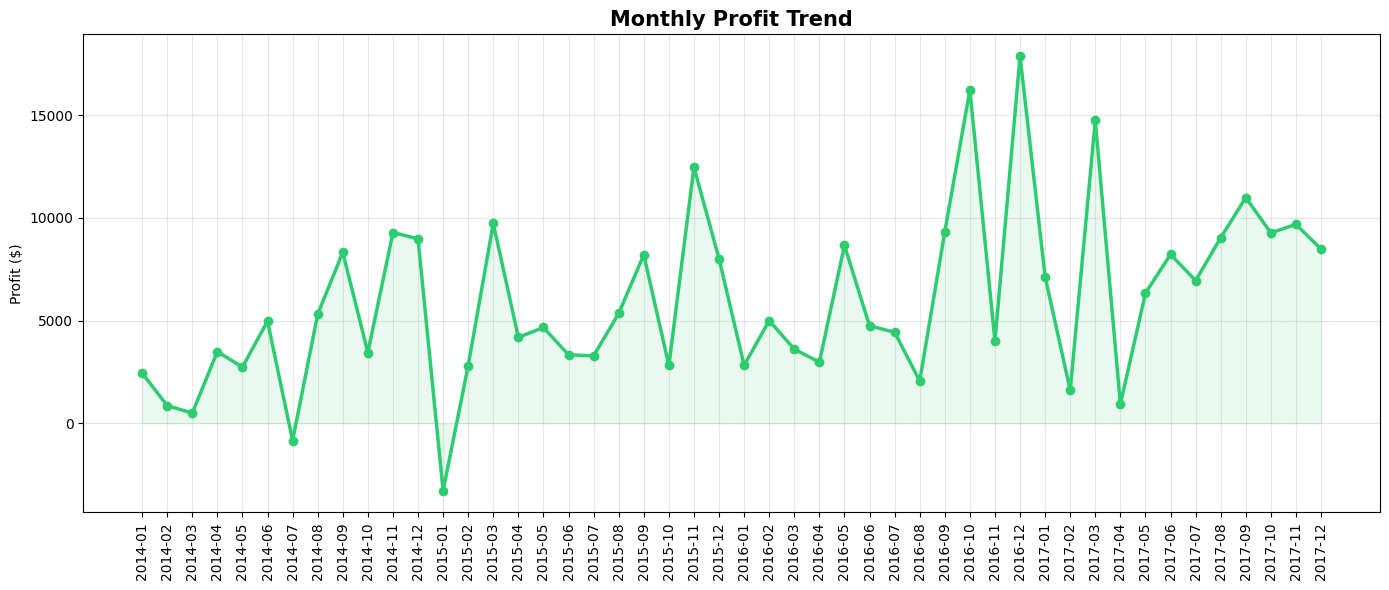

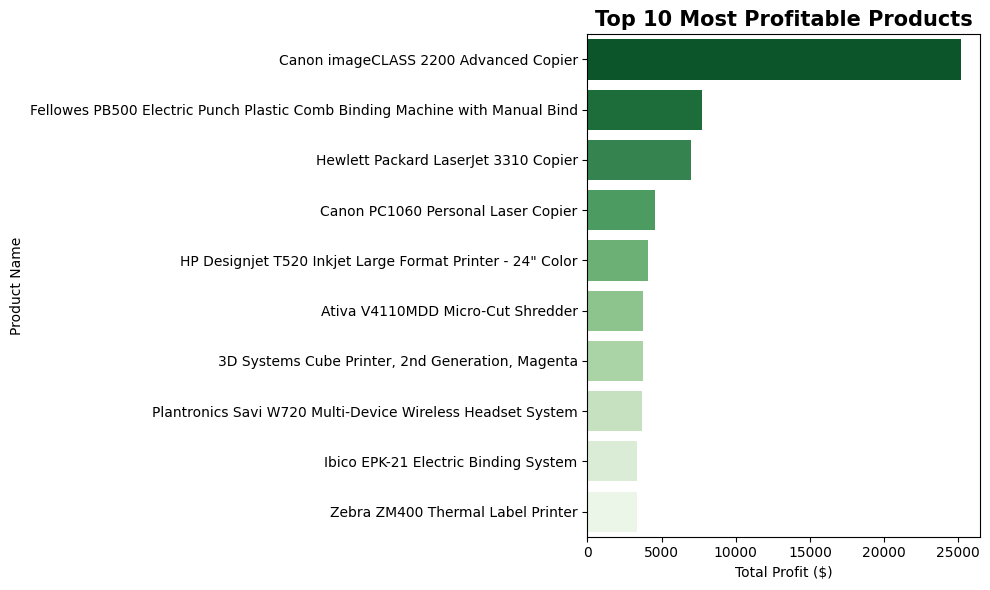

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

# Sales by Category
plt.figure(figsize=(10, 6))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=category_sales, x='Category', y='Sales', palette='magma', hue='Category', legend=False)
plt.title('Total Sales by Category', fontsize=15, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Monthly Profit Trend
monthly_data = df.groupby('Month')['Profit'].sum().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(monthly_data['Month'], monthly_data['Profit'], marker='o', color='#2ecc71', linewidth=2.5)
plt.fill_between(monthly_data['Month'], monthly_data['Profit'], color='#2ecc71', alpha=0.1)
plt.title('Monthly Profit Trend', fontsize=15, fontweight='bold')
plt.xticks(rotation=90)
plt.ylabel('Profit ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Top 10 Products by Profit
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, y='Product Name', x='Profit', palette='Greens_r', hue='Product Name', legend=False)
plt.title('Top 10 Most Profitable Products', fontsize=15, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.show()